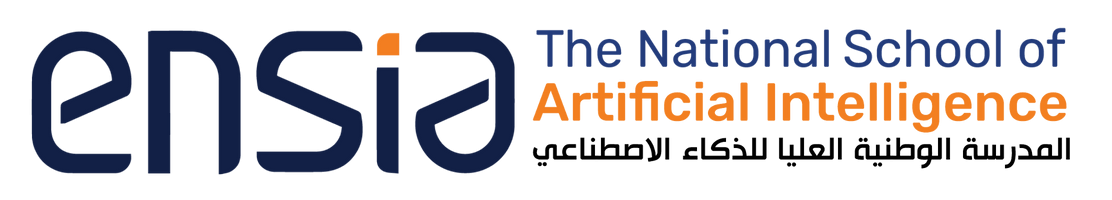

# **Overview**

> Building on the previous lab, this session is split into two parts. In the first part, you’ll dive into the **SMO** algorithm: we’ll provide a thorough explanation and a hands-on example that benchmarks your implementation against scikit-learn’s SVM. At its core, SMO breaks the SVM’s constrained quadratic optimization into a sequence of **two-variable subproblems**, updating just two Lagrange multipliers at a time until all are optimized.

> This Lab constitutes the following Two parts:
>
> ✅**Dual SVM With SMO** –.
>
> ✅**Intoduction to Artificial Neural Network (ANN)** –.


---
# **PART I: SVM with SMO**
---

> One of the most common and efficient approaches to train SVM is sequential minimal optimisation (SMO), which breaks down the problem into solving a pair of parameters analytically at each step. Besides, SMO also eliminates the need for matrix storage issue when the training data size is huge.

## **Formulation**

Remember the dual formulation:
>$$ \pmb{l = \sum_{i=1}^{m} \alpha_i - \frac{1}{2} \sum_{i=1}^{m}\sum_{j=1}^{m} \alpha_i ⋅ \alpha_j ⋅  t_i ⋅ t_j ⋅ K(x_i, x_j)}
$$

Subject to the linear constraints:

>$$
\pmb{\sum_{i=1}^{m} \alpha_i ⋅ t_i = 0, \quad 0 \leq \alpha_i \leq C}
$$

SMO breaks this big m-dimensional QP into many tiny 2-dimensional subproblems (one pair of α’s at a time instead of all α), each of which can be solved analytically in constant time.

### **2-demensional sub-problem formulation**
The optimization problem consists of maximizing $l(\alpha_1, \alpha_2)$ for each two alphas (all others are fixed), it could be reformulated as follows:

$$\boxed{l(α_1, \alpha_2) = α_1 + α_2 - \frac{1}{2} (α_1^2 ⋅ K_{11} + α_2^2 ⋅ K_{22} - 2 α_1 ⋅ α_2 ⋅ t_1 ⋅ t_2 ⋅ K_{12}) + Constant}$$
<details>
  <summary>💡(Click for more details)</summary>

---

>🎯 **Goal**
>
> We are starting from the dual form of the SVM objective:
>
> We want to update only two variables,
$\alpha_1$ and $\alpha_2$ , while keeping all others fixed. So, we focus only on the part of the objective that includes $\alpha_1$ and $\alpha_2$. Everything else becomes a constant and doesn’t affect optimization.
>
>🔍 **Step-by-step: Isolate terms involving α₁ and α₂**
>
>From the double sum: $\sum_{i=1}^{m}\sum_{j=1}^{m} \alpha_i ⋅ \alpha_j ⋅  t_i ⋅ t_j ⋅ K(x_i, x_j)$ We want to keep only the terms involving:
- $α_1^2$
- $α_2^2$
- $α_1 ⋅ α_2$
>
>Let’s extract just those terms explicitly.
>
>✴️ The relevant terms:
>From the double sum, the terms involving $α_1$ and $α_2$ are:
- $\alpha_1^2 ⋅ t_1^2 ⋅ K(x_1, x_1) = α_1^2 ⋅ K_{11}$ (since t_1^2 = 1)
- $\alpha_2^2 ⋅ t_2^2 ⋅ K(x_2, x_2) = α_2^2 ⋅ K_{22}$ (since t_2^2 = 1)
- $2 ⋅ \alpha_1 ⋅ \alpha_2 ⋅ t_1 ⋅ t_2 ⋅ K(x_1, x_2) = 2 ⋅ \alpha_1 ⋅ \alpha_2 ⋅ t_1 ⋅ t_2 ⋅ K_{12}$
>
>🧠 Why 2 here? Because in the double sum both (i=1,j=2) and (i=2,j=1) show up — they’re symmetric and contribute the same value.

---
</details>

Subject to:

1. 🔸Box constraints: $0 ≤ α_1, α_2 ≤ C$
2. 🔸Equality constraint $t_1 ⋅ Δ \alpha_1 + t_2 ⋅ Δ \alpha_2 = 0 \quad \quad$ ($Δ \alpha_1 = \alpha_1^{new} - \alpha_1^{old}$)

<details>
  <summary>💡(Click for more details) </summary>

---

> The equality constraint of dual formulation is:
>
> $\sum_{i}^{n} t_i ⋅ \alpha_i = 0 ⇒ \alpha_1 ⋅ t_1 + \alpha_2 ⋅ t_2 + \sum_{j = 3}^{n} t_j ⋅ \alpha_j = 0$
>
>Because in the 2-dimensional sub-problem all other term are fixed then: $\sum_{j = 3}^{n} t_j ⋅ \alpha_j = Constant$.
>
>$\alpha_1^{old} \cdot t_1 + \alpha_2^{old} \cdot t_2 = Constant = \alpha_1^{new} \cdot t_1 + \alpha_2^{new} \cdot t_2$
>
>$⇒ (\alpha_1^{old} + Δ\alpha_1) \cdot t_1 + (\alpha_2^{old} + Δ\alpha_2) \cdot t_2 = \alpha_1^{old} \cdot t_1 + \alpha_2^{old} \cdot t_2$
>
>Cancel out the common terms:
>
>$⇒ t_1 ⋅ Δ\alpha_1 + t_2 ⋅ Δ\alpha_2 = 0$
---

</details>

<!-- $\alpha_1^{new} = \alpha_1^{old} + t_1 ⋅ t_2 ⋅ (\alpha_2^{old} - \alpha_2^{new})$ -->

***
### **Update $α_1$**:

Remember that the aim is to update $α_i$ and $\alpha_j$ to maximize $l(α_i,α_j)$ while respecting Box and Equality constraints. from the Equality Constraint, We can calculate the new updated $α_1$ as follows:

$$
\alpha_1^{new} = \alpha_1^{old} + t_1 ⋅ t_2 ⋅ (\alpha_2^{old} - \alpha_2^{new})
$$

This ensures the equality Constraint is satisfied. **But how do we calculate $α_2^{new}$ ?**

### **Update $α_2$**:
The formula of the new updated $\alpha_2^{raw}$ is as follows:
$$
\alpha_2^{\rm raw}
   = \alpha_2^{\rm old}
     \;+\;
     \frac{t_2\,(E_1 - E_2)}{\eta}
$$
Where:
- $\eta = K_{11} + K_{22} - 2K_{12}$
- $E_k = f(x_k) - t_k$

It was obtained by substituting $α_1$ with its equivalent formula containing $α_2$
<details>
  <summary>💡(Click to see the linear algebra details)
  </summary>

---
1. **Two-variable objective**  
   $$
   l(\alpha_i,\alpha_j)
   = \alpha_i + \alpha_j
   \;-\;\frac12\Bigl(
       K_{ii}\,\alpha_i^2
     + 2\,t_i\,t_j\,K_{ij}\,\alpha_i\,\alpha_j
     + K_{jj}\,\alpha_j^2
   \Bigr)
   + \text{const.}
   $$

2. **Equality-constraint substitution**  
   $$
   t_i\,\alpha_i + t_j\,\alpha_j = \zeta
   \;\;\Longrightarrow\;\;
   \alpha_i
   = \alpha_i^{\rm old}
     + t_i\,t_j\,\bigl(\alpha_j^{\rm old} - \alpha_j\bigr).
   $$

3. **Reduced one-dimensional quadratic**  
   After substituting the above into (l), we get:
   $$
  W(\alpha_j)
  = \bigl(\alpha_i^{\rm old} + t_i t_j(\alpha_j^{\rm old}-\alpha_j)\bigr)
    + \alpha_j
    - \tfrac12\Bigl[
        K_{ii}\bigl(\alpha_i^{\rm old} + t_i t_j(\alpha_j^{\rm old}-\alpha_j)\bigr)^{2}
      + 2\,t_i t_j\,K_{ij}\,\bigl(\alpha_i^{\rm old} + t_i t_j(\alpha_j^{\rm old}-\alpha_j)\bigr)\,\alpha_j
      + K_{jj}\,\alpha_j^{2}
    \Bigr]
    + \text{const}.
  $$

   After simplifying, we get
   $$
   l(\alpha_j)
   = -\tfrac12\,\eta\,\alpha_j^2
     \;+\;t_j\,(E_i - E_j)\,\alpha_j
     \;+\;\text{const},
   $$
   where
   $$
   \eta = K_{ii} + K_{jj} - 2K_{ij},
   \quad
   E_k = f(x_k) - t_k,
   \quad
  f(x_k) = \sum_{i=1}^{n} \alpha_i t_i K(x_i, x_k) + b
   $$

4. **Derivative and raw update**  
   Taking ($\frac{dl}{d\alpha_j}=0$) gives
   $$
   \frac{dW}{d\alpha_j}
   = -\,\eta\,\alpha_j
     + y_j\,(E_i - E_j)
   = 0
   \;\;\Longrightarrow\;\;
   \boxed{
   \alpha_j^{\rm raw}
   = \alpha_j^{\rm old}
     \;+\;
     \frac{y_j\,(E_i - E_j)}{\eta}
     }
   $$
---

</details>

The newly calculated $α_2^{raw}$ does respect the equality constaint, but we need to force it to respect the box constraint, for which we need to clip it into the range of [0, C].

### **Calculation Higher and Lower bounds for the box constaint:**
Because we replaced $α_1$ with $\alpha_1^{\rm old} + t_1\,t_2\,\bigl(\alpha_2^{\rm old} - \alpha_2\bigr)$, the requirement $0 ≤ α_1 ≤ C$ translates into bounds $L$ and $H$ on $α_2$. We distinguish two different cases to determine these bounds:

$$
L = \max(0, \alpha_2^{\rm old} - \alpha_1^{\rm old}), \quad H = \min(C, C+ \alpha_2^{\rm old} - \alpha_1^{\rm old}) \quad if \quad t_1 = t_2
$$
$$
L = \max(0, \alpha_1^{\rm old} + \alpha_2^{\rm old} - C), \quad H = \min(C, \alpha_1^{\rm old} + \alpha_2^{\rm old}) \quad if \quad t_1 \neq t_2
$$
<details>
  <summary>💡(Click for more details)
  </summary>

---
From the “sum-to-zero” constraint  
$$
t_i\,\Delta\alpha_i + t_j\,\Delta\alpha_j = 0
\;\;\Longrightarrow\;\;
\alpha_i = \alpha_i^{\rm old} + t_i\,t_j\,\bigl(\alpha_j^{\rm old}-\alpha_j\bigr),
$$
we substitute into ($0 \le \alpha_i \le C$):

1. **Lower bound on ($\alpha_i$)**  
   $$
   0 \le \alpha_i^{\rm old} + t_i\,t_j\,(\alpha_j^{\rm old}-\alpha_j)
   \;\Longrightarrow\;
   t_i\,t_j\,(\alpha_j^{\rm old}-\alpha_j) \ge -\,\alpha_i^{\rm old}
   \;\Longrightarrow\;
   \alpha_j \le \alpha_j^{\rm old} + t_i\,t_j\,\alpha_i^{\rm old}.
   $$

2. **Upper bound on ($\alpha_i$)**  
   $$
   \alpha_i^{\rm old} + t_i\,t_j\,(\alpha_j^{\rm old}-\alpha_j) \le C
   \;\Longrightarrow\;
   t_i\,t_j\,(\alpha_j^{\rm old}-\alpha_j) \le C - \alpha_i^{\rm old}
   \;\Longrightarrow\;
   \alpha_j \ge \alpha_j^{\rm old} - t_i\,t_j\,(C - \alpha_i^{\rm old}).
   $$

We also require the box-constraint on ($\alpha_j$):
We have :
$$
0 \le \pmb{\alpha_j} \le C.
$$
and
$$\alpha_j^{\rm old} - t_i\,t_j\,(C - \alpha_i^{\rm old}) \le \pmb{\alpha_j} \le \alpha_j^{\rm old} + t_i\,t_j\,\alpha_i^{\rm old}$$

Combining all four inequalities gives the feasible interval ($[L,H]$) for($\alpha_j$):

- **If ($t_i = t_j ⇒ t_i \cdot t_j=+1$)**:  
  $$
  L = \max\bigl(0,\;\alpha_i^{\rm old}+\alpha_j^{\rm old}-C\bigr),
  \quad
  H = \min\bigl(C,\;\alpha_i^{\rm old}+\alpha_j^{\rm old}\bigr).
  $$

- **If ($t_i \neq t_j ⇒ t_i \cdot t_j= -1$)**:  
  $$
  L = \max\bigl(0,\;\alpha_j^{\rm old}-\alpha_i^{\rm old}\bigr),
  \quad
  H = \min\bigl(C,\;C + \alpha_j^{\rm old}-\alpha_i^{\rm old}\bigr).
  $$
---

</details>

Finally, we clip the raw update $(\alpha_j^{\rm raw}) \text{ into } ([L,H]) \text{ to obtain } (\alpha_j^{\rm new})$

$$
\alpha_2^{new} =
\begin{cases}
H & \text{if } \alpha_2^{raw} > H \\
L & \text{if } \alpha_2^{raw} < L \\
\alpha_2^{raw} & \text{otherwise}
\end{cases}
$$

### **Update the bias term b:**
Now, after updating both $\alpha_1$ $\alpha_2$ we must recompute $b$ using the updated $α_1^{new}$ and $α_1^{new}$,

$$
b_{1} = b_{\rm old}
- E_1
- t_1\,(\alpha_1^{\rm new}-\alpha_1^{\rm old})\,K(\mathbf{x}_1,\mathbf{x}_1)
- t_2\,(\alpha_2^{\rm new}-\alpha_2^{\rm old})\,K(\mathbf{x}_2,\mathbf{x}_2)
$$
$$
b_{2} = b_{\rm old}
- E_2
- t_1\,(\alpha_1^{\rm new}-\alpha_1^{\rm old})\,K(\mathbf{x}_1,\mathbf{x}_2)
- t_2\,(\alpha_2^{\rm new}-\alpha_2^{\rm old})\,K(\mathbf{x}_2,\mathbf{x}_2)
$$
<details>
  <summary>💡(Click for more details)
  </summary>

---
>#### **Deriving the $b_{1}$ Bias Update**
>
>When we update only two multipliers $\alpha_i$ and $\alpha_j$, we must also adjust the bias $b$ so that at least one “free” support vector still lies exactly on the margin.  Here is the step-by-step derivation of the formula for $b_{1}$.
>
>1. **Margin condition**
>
>For a free support vector $i$ (i.e.\ $0 < \alpha_i < C$), after the update we require
$$
t_i\bigl(f_{\rm new}(\mathbf{x}_i) + b_{\rm new}\bigr) \;=\; 1.
$$
>
>2. **New decision function at $\mathbf{x}_i$**
>
>The decision function is
$$
f(\mathbf{x})
= \sum_{k=1}^n \alpha_k\,t_k\,K(\mathbf{x}_k,\mathbf{x}) \;+\; b.
$$
>Only $\alpha_i$ and $\alpha_j$ change, so the increment at $\mathbf{x}_i$ is
$$
\Delta f(\mathbf{x}_i)
= (\alpha_i^{\rm new}-\alpha_i^{\rm old})\,t_i\,K(\mathbf{x}_i,\mathbf{x}_i)
+ (\alpha_j^{\rm new}-\alpha_j^{\rm old})\,t_j\,K(\mathbf{x}_j,\mathbf{x}_i).
$$
>Thus
$$
f_{\rm new}(\mathbf{x}_i)
= f_{\rm old}(\mathbf{x}_i)
+ (\alpha_i^{\rm new}-\alpha_i^{\rm old})\,t_i\,K(\mathbf{x}_i,\mathbf{x}_i)
+ (\alpha_j^{\rm new}-\alpha_j^{\rm old})\,t_j\,K(\mathbf{x}_j,\mathbf{x}_i).
$$
>
>3. **Plug into the margin equation**
>
>We want
$$
f_{\rm new}(\mathbf{x}_i) + b_{\rm new} = t_i
\quad\Longrightarrow\quad
b_{\rm new} = t_i - f_{\rm new}(\mathbf{x}_i).
$$
>
>4. **Use the old bias and error**
>
>Define the old prediction error
$$
E_i = f_{\rm old}(\mathbf{x}_i) + b_{\rm old} - t_i
\;\Longrightarrow\;
t_i - f_{\rm old}(\mathbf{x}_i) = b_{\rm old} - E_i.
$$
>Substitute into the expression for $b_{\rm new}$:
>
>\begin{aligned}
b_{\rm new}
&= \bigl(b_{\rm old} - E_i\bigr)
- (\alpha_i^{\rm new}-\alpha_i^{\rm old})\,t_i\,K(\mathbf{x}_i,\mathbf{x}_i)\\
&\quad
- (\alpha_j^{\rm new}-\alpha_j^{\rm old})\,t_j\,K(\mathbf{x}_j,\mathbf{x}_i).
\end{aligned}
>
>5. **Final boxed formula**
>
>We call this candidate $b_{1}$:
$$
\boxed{
b_{1} = b_{\rm old}
- E_i
- t_i\,(\alpha_i^{\rm new}-\alpha_i^{\rm old})\,K(\mathbf{x}_i,\mathbf{x}_i)
- t_j\,(\alpha_j^{\rm new}-\alpha_j^{\rm old})\,K(\mathbf{x}_j,\mathbf{x}_i)
}.
$$
>
---
>#### **Deriving the $b_{2}$ Bias Update**
>
>We derive $b_{2}$ by enforcing the margin condition on the second updated point $j$.
>
>1. **Margin condition at $j$**
>
>For a free support vector $j$ (i.e.\ $0 < \alpha_j < C$), we require
$$
t_j\bigl(f_{\rm new}(\mathbf{x}_j) + b_{\rm new}\bigr) = 1.
$$
>
>2. **Change in the decision function at $\mathbf{x}_j$**
>
>Recall
$$
f(\mathbf{x})
= \sum_{k=1}^n \alpha_k\,t_k\,K(\mathbf{x}_k,\mathbf{x}) + b.
$$
Only $\alpha_i$ and $\alpha_j$ change, so the increment at $\mathbf{x}_j$ is
$$
\Delta f(\mathbf{x}_j)
= (\alpha_i^{\rm new}-\alpha_i^{\rm old})\,t_i\,K(\mathbf{x}_i,\mathbf{x}_j)
+ (\alpha_j^{\rm new}-\alpha_j^{\rm old})\,t_j\,K(\mathbf{x}_j,\mathbf{x}_j).
$$
Thus
$$
f_{\rm new}(\mathbf{x}_j)
= f_{\rm old}(\mathbf{x}_j)
+ (\alpha_i^{\rm new}-\alpha_i^{\rm old})\,t_i\,K(\mathbf{x}_i,\mathbf{x}_j)
+ (\alpha_j^{\rm new}-\alpha_j^{\rm old})\,t_j\,K(\mathbf{x}_j,\mathbf{x}_j).
$$
>
>3. **Plugging into the margin equation**
>
>We want
$$
f_{\rm new}(\mathbf{x}_j) + b_{\rm new} = t_j
\quad\Longrightarrow\quad
b_{\rm new} = t_j - f_{\rm new}(\mathbf{x}_j).
$$
>
>4. **Use the old bias and error**
>
>Define the old prediction error
$$
E_j = f_{\rm old}(\mathbf{x}_j) + b_{\rm old} - t_j
\quad\Longrightarrow\quad
t_j - f_{\rm old}(\mathbf{x}_j) = b_{\rm old} - E_j.
$$
Substitute into $b_{\rm new}$:
\begin{aligned}
b_{\rm new}
&= \bigl(b_{\rm old} - E_j\bigr)
- (\alpha_i^{\rm new}-\alpha_i^{\rm old})\,t_i\,K(\mathbf{x}_i,\mathbf{x}_j)\\
&\quad
- (\alpha_j^{\rm new}-\alpha_j^{\rm old})\,t_j\,K(\mathbf{x}_j,\mathbf{x}_j).
\end{aligned}
>
>5. **Final boxed formula**
>
>This candidate is called $b_{2}$:
$$
\boxed{
b_{2} = b_{\rm old}
- E_j
- t_i\,(\alpha_i^{\rm new}-\alpha_i^{\rm old})\,K(\mathbf{x}_i,\mathbf{x}_j)
- t_j\,(\alpha_j^{\rm new}-\alpha_j^{\rm old})\,K(\mathbf{x}_j,\mathbf{x}_j)
}.
$$

---

</details>

The new Bias **$b$** is determined as follows:

$$
b^{new} =
\begin{cases}
b_1 & \text{if } 0 < \alpha_1^{new} < C \\
b_2 & \text{if } 0 < \alpha_2^{new} < C \\
\frac{b_1 + b_2}{2} & \text{otherwise}
\end{cases}
$$

# Implementation

## Helper Functions

In [6]:
#------------Imports-------------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import pandas as pd

#------------Generate data-------------
def load_circle_data():

    def gen_circle(n=50, center_x=0, center_y=0, radius=1, label=0):
      alpha = 2 * np.pi * np.random.rand(n)
      r = radius * np.sqrt(np.random.rand(n))
      x = r * np.cos(alpha) + center_x
      y = r * np.sin(alpha) + center_y
      return x, y, np.ones(n) * label
    np.random.seed(5)
    n = 100
    C0 = gen_circle(n, center_x=1, center_y=1, radius=1.05, label=1)
    C1 = gen_circle(n, center_x=-1, center_y=-1, radius=1.05, label=-1)
    X = np.c_[np.append(C0[0], C1[0]), np.append(C0[1], C1[1])]
    Y = np.append(C0[2], C1[2])
    return X, Y
#------------Plotting------------------

def plot_decision_boundary(model, X, y, title):
    """
    Plot decision boundary and support vectors for any SVM-like model.

    model: object with methods
        - predict(X) returning decision values OR
        - decision_function(X) returning decision values
    scaler: fitted scaler to transform grid points
    X: original feature matrix (unscaled) of shape (m, 2)
    y: labels vector of shape (m,), values in {-1, +1}
    title: plot title (string)
    """
    # Create grid over feature space
    x_min, x_max = X[:,0].min(), X[:,0].max()
    y_min, y_max = X[:,1].min(), X[:,1].max()
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Scale grid
    grid_scaled = standardize(grid)

    # Get decision values
    if hasattr(model, "decision_function"):
        Z = model.decision_function(grid_scaled)
    else:
        Z = model.predict(grid_scaled)
    Z = Z.reshape(xx.shape)

    # Plot contours
    plt.figure()
    plt.contour(xx, yy, Z, levels=[-1, 0, 1], linestyles=['--', '-', '--'])

    # Plot data points
    plt.scatter(X[y== 1, 0], X[y== 1, 1], marker='o', label='+1')
    plt.scatter(X[y==-1, 0], X[y==-1, 1], marker='x', label='-1')

    # Plot support vectors (non-zero alphas or sklearn support_)
    if hasattr(model, "alphas"):
        sv_mask = model.alphas > 1e-8
        plt.scatter(X[sv_mask,0], X[sv_mask,1], marker='*', s=100, label='SVs')
    elif hasattr(model, "support_"):
        plt.scatter(X[model.support_,0], X[model.support_,1], marker='*', s=100, label='SVs')

    plt.title(title)
    plt.legend()
    plt.show()

#------------Standardize------------------
def standardize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    # Replace zeros in std with 1 to avoid division by zero
    std[std == 0] = 1e-6
    return (X - mean) / std

## **Class Structure and buisiness logic**

### **`SVM_SMO`** Workflow Story

Think of `SVM_SMO` as your automated “knob-tweaker” for fitting a maximal-margin classifier. Here’s what happens under the hood:

1. **Setup (`__init__` and `__fit__`)**  
   - When you call `fit(X, y)`, the model records `m` (number of examples) and `n` (number of features), initializes all Lagrange multipliers `α_i` to zero, resets the bias `b`, and clears the error cache.

2. **Outer Loop (`__fit__`)**  
   - The algorithm alternates between  
     - a **full-data pass** (examining every example for KKT violations) and  
     - a **non-bound pass** (examining only the “working set” of interior multipliers where $(0 < α_i < C)$).  
   - If a non-bound pass makes no updates, it switches back to a full pass.  
   - It stops when an entire full-data pass yields zero changes (or when `max_iter` is reached).

<details>  
   
<summary>💡(Click to see the KKT violations).</summary>

---

>Violations:
>
>$$
\alpha_i = 0 \quad \text{but} \quad t_i \cdot f(x_i) < 1 \quad \text{(misclassified)}
$$
>
>$$
0 < \alpha_i < C \quad \text{but} \quad t_i \cdot f(x_i) \neq 1 \quad \text{(on the margin)}
$$
>
>$$
\alpha_i = C \quad \text{but} \quad t_i \cdot f(x_i) > 1 \quad \text{(inside the margin)}
$$
---

</details>



3. **Examining an Example (instance)**  
   - In `examine_example(i_2)`, compute the error $(E_2 = f(x_{i_2}) - t_{i_2})$ and check the KKT conditions.  
   - If example $(i_2)$ violates, select a partner $(i_1)$ as follows:  
     1. The non-bound index with the largest $(|E_1 - E_2|)$.  
     2. Randomly among non-bound examples.  
     3. Randomly among all examples.  
   - Call `take_step(i_1, i_2)` to jointly update $(α_{i_1}, α_{i_2})$.

4. **Updating a Pair**  
   - Compute the feasible interval $([L,H])$ that enforces $(0 ≤ α ≤ C)$ and $(\sum α_i y_i = 0)$.  
   - Calculate $(\eta = K(x,x₁) + K(x₂,x₂) - 2·K(x₁,x₂))$.  
   - Solve for the unclipped $(α_2^{raw} = α_2 + \frac{y_2\,(E_1 - E_2)}{\eta})$, then clip it to $([L,H])$ (to get $α_2^{new}$).  
   - Update $(α_1^{new} = α_1 + t_1 t_2\,(α_2 - α_2^{new}))$.  
   - Compute two bias candidates  
     $$
       b_1, b_2 = b - E_i - \sum \Delta\alpha\, K(\cdot,\cdot)
      $$  
     and choose the correct new $(b)$.  
   - If using a linear kernel, recompute the weight vector  
     $(w = \sum_i α_i \cdot y_i \cdot x_i)$.  
   - Refresh the error cache for any $(\alpha_i)$ still in $(0,C)$.

5. **Making Predictions**  
   - After fitting, `predict(X_test)` computes  
     $$
       f(x) = \sum_i α_i \cdot  y_i \cdot K(x_i,x) + b
     $$  
     and returns the raw decision scores for each test point.

In [7]:
import numpy as np
import random

class SVM_SMO:
    def __init__(self, C=1.0, kernel='linear', b=0.0,
                 max_iter=300, tol=1e-5, eps=1e-8):
        """
        Initialize the SVM-SMO model.

        Parameters:
        C        : regularization strength
        kernel   : 'linear' or 'rbf'
        b        : initial bias term
        max_iter : maximum outer-loop iterations
        tol      : KKT tolerance threshold
        eps      : numerical stability constant
        """
# --------------------------------------------------------------------------
        # STEP 1: Attributes initialization
# --------------------------------------------------------------------------
        self.X = None            # training data (m x n)
        self.y = None            # labels (length m)
        self.m = 0               # number of samples
        self.n = 0               # number of features
        self.C = C               # regularization parameter
        self.alphas = None       # Lagrange multipliers α
        self.b = b               # bias term b
        self.error = None        # error cache E_i
# --------------------------------------------------------------------------
        # STEP 2: Kernel selection
# --------------------------------------------------------------------------
        if kernel == 'linear':
            self.kernel_func = self.linear_kernel
            self.is_linear = True
        elif kernel in ('rbf', 'gaussian'):
            self.kernel_func = self.gaussian_kernel
            self.is_linear = False
        else:
            raise ValueError(f"Unknown kernel: {kernel}")
# --------------------------------------------------------------------------
        # STEP 3: SMO control parameters
# --------------------------------------------------------------------------
        self.max_iter = max_iter
        self.tol      = tol
        self.eps      = eps
# --------------------------------------------------------------------------
        # STEP 4: For linear kernel, initialize w
# --------------------------------------------------------------------------
        self.w = None

    def linear_kernel(self, x1, x2):
        """Compute linear kernel: K(x1, x2) = x1 · x2"""
        x1_arr = np.asarray(x1)
        x2_arr = np.asarray(x2)
        # 1D-1D -> scalar dot
        if x1_arr.ndim == 1 and x2_arr.ndim == 1:
            return np.dot(x1_arr, x2_arr)
        # 2D-2D or mixed -> Gram matrix
        return np.dot(x1_arr, x2_arr.T)

    def gaussian_kernel(self, x1, x2, sigma=1.0):
        """
        Compute RBF kernel: exp(-||x1-x2||^2 / (2σ^2)).
        Handles both 1D and 2D inputs.
        """
        x1_arr = np.asarray(x1)
        x2_arr = np.asarray(x2)
        # single-sample vs single-sample
        if x1_arr.ndim == 1 and x2_arr.ndim == 1:
            diff = x1_arr - x2_arr
            return np.exp(-np.sum(diff**2) / (2 * sigma**2))
        # promote to 2D
        if x1_arr.ndim == 1:
            x1_arr = x1_arr[np.newaxis, :]
        if x2_arr.ndim == 1:
            x2_arr = x2_arr[np.newaxis, :]
        # pairwise distances
        diff = x1_arr[:, None, :] - x2_arr[None, :, :]
        sq_dist = np.sum(diff**2, axis=2)
        return np.exp(-sq_dist / (2 * sigma**2))

    def predict(self, X_test):
        """
        STEP 5: Prediction f(x) = Σ α_i y_i K(x_i, x) + b
        Returns raw decision scores.
        """
        X_test = np.atleast_2d(X_test)
        K = self.kernel_func(self.X, X_test)  # shape (m_train, m_test)

        return (self.alphas * self.y).dot(K) + self.b

    def get_error(self, i):
        """
        STEP 6: Error computation E_i = f(x_i) - y_i
        """
        # kernel of all train points vs x_i
        K_i = self.kernel_func(self.X, self.X[i:i+1]).flatten()
        # decision value at x_i
        f_i = (self.alphas * self.y).dot(K_i) + self.b
        return f_i - self.y[i]

    def take_step(self, i1, i2):
        """
        STEP 7: Optimize pair (i1, i2).
        Returns 1 on successful update, else 0.
        """
        # skip same index
        if i1 == i2:
            return 0
        x1, x2 = self.X[i1], self.X[i2]
        t1, t2 = self.y[i1], self.y[i2]
        a1, a2 = self.alphas[i1], self.alphas[i2]
        E1, E2 = self.error[i1], self.error[i2]
# --------------------------------------------------------------------------
        # STEP 7a: Compute L, H (feasible bounds)
# --------------------------------------------------------------------------
        if t1 != t2: # First case
            L = max(0, a2 - a1)
            H = min(self.C, self.C + a2 - a1)
        else:        # Second case
            L = max(0, a1 + a2 - self.C)
            H = min(self.C, a1 + a2)
        if L >= H:
            return 0
# --------------------------------------------------------------------------
        # STEP 7b: Compute η (second derivative)
# --------------------------------------------------------------------------
        k11 = self.kernel_func(x1, x1)
        k12 = self.kernel_func(x1, x2)
        k22 = self.kernel_func(x2, x2)
        eta = k11 + k22 - 2 * k12
        if eta <= 0:
            return 0
# --------------------------------------------------------------------------
        # STEP 7c: Compute & clip α2
# --------------------------------------------------------------------------
        a2_raw = a2 + t2 * (E1 - E2) / eta
        a2_new = np.clip(a2_raw, L, H)
        if abs(a2_new - a2) < self.eps * (a2 + a2_new + self.eps):
            return 0
# --------------------------------------------------------------------------
        # STEP 7d: Update α1 to maintain ∑ αy = 0
# --------------------------------------------------------------------------
        a1_new = a1 + t1 * t2 * (a2 - a2_new)
# --------------------------------------------------------------------------
        # STEP 7e: Compute b1, b2 candidates
# --------------------------------------------------------------------------
        b1 = self.b - E1 - t1 * k11 * (a1_new - a1) - t2 * k12 * (a2_new - a2)
        b2 = self.b - E2 - t1 * k12 * (a1_new - a1) - t2 * k22 * (a2_new - a2)
# --------------------------------------------------------------------------
        # STEP 7f: Select new bias b
# --------------------------------------------------------------------------
        if 0 < a1_new < self.C:
            self.b = b1
        elif 0 < a2_new < self.C:
            self.b = b2
        else:
            self.b = (b1 + b2) / 2
# --------------------------------------------------------------------------
        # STEP 7g: Update weight vector (if linear)
# --------------------------------------------------------------------------
        if self.is_linear:
            self.w = np.sum(self.alphas[:, np.newaxis] * self.y[:, np.newaxis] * self.X, axis=0)
# --------------------------------------------------------------------------
        # STEP 7h: Commit updated alphas
# --------------------------------------------------------------------------
        self.alphas[i1], self.alphas[i2] = a1_new, a2_new
# --------------------------------------------------------------------------
        # STEP 7i: Refresh error cache
# --------------------------------------------------------------------------
        idxs = np.where((self.alphas > 0) & (self.alphas < self.C))[0]
        for i in idxs:
            self.error[i] = self.get_error(i)
        return 1

    def examine_example(self, i2):
        """
        STEP 8: Check KKT for index i2 and choose partner i1.
        Returns 1 if a pair update occurs.
        """
# --------------------------------------------------------------------------
        # STEP 8: Choose instances and update alphas
# --------------------------------------------------------------------------
        t2 = self.y[i2]
        a2 = self.alphas[i2]
        E2 = self.error[i2]
        r2 = E2 * t2
        # violation check, Instead of 0 choose tol

        # Case A: α2 == 0 but r2 < 0 (should be ≥ 0)
        viol_1 = (a2 < self.tol) and (r2 < -self.tol)

        # Case B: 0 < α2 < C but |r2| > 0 (should be == 0)
        viol_2 = (self.tol <= a2 <= self.C - self.tol) and (abs(r2) > self.tol)

        # Case C: α2 == C but r2 > 0 (should be ≤ 0)
        viol_3 = (a2 > self.C - self.tol) and (r2 > self.tol)

        if viol_1 or viol_2 or viol_3:
            # 1) pick max|E1-E2|
            idxs = np.where((self.alphas > 0) & (self.alphas < self.C))[0]
            if len(idxs) > 1:
                i1 = idxs[np.argmax(np.abs(self.error[idxs] - E2))]
                if self.take_step(i1, i2):
                    return 1
            # 2) random non-bound
            for i1 in np.random.permutation(self.m):
                if 0 < self.alphas[i1] < self.C:
                    if self.take_step(i1, i2):
                        return 1
            # 3) random all
            for i1 in np.random.permutation(self.m):
                if self.take_step(i1, i2):
                    return 1

        return 0

    def fit(self, X, y):
        """
        STEP 9: Outer loop alternating full/non-bound scans.
        """
# --------------------------------------------------------------------------
        # STEP 9: Fit the algorithm (the outer loop for the SMO)
# --------------------------------------------------------------------------
        self.X, self.y = X, y
        self.m, self.n = X.shape
        self.alphas = np.zeros(self.m)
        self.b = 0
        self.error = np.zeros(self.m)

        if self.is_linear:
            self.w = np.zeros(self.n)

        num_changed = 0
        examine_all = True
        iteration = 0

        while iteration < self.max_iter and (num_changed > 0 or examine_all):
            num_changed = 0
            if examine_all:
                # FULL pass: examine each sample
                for i in range(self.m):
                    num_changed += self.examine_example(i)
                examine_all = False
            else:
                # NON-BOUND pass: examine only working set
                idxs = np.where((self.alphas > 0) & (self.alphas < self.C))[0]
                for i in idxs:
                    num_changed += self.examine_example(i)
                if num_changed == 0:
                    examine_all = True
            iteration += 1
        # END STEP 9: Converged or reached max_iter

# Check it against SKlearn's model

         Model  SV Count      Bias  Error Rate
Custom SVM_SMO         0  0.000000         0.0
   sklearn SVC        14 -0.011575         0.0


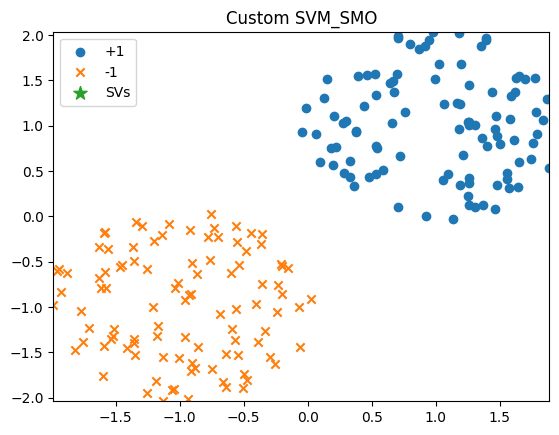

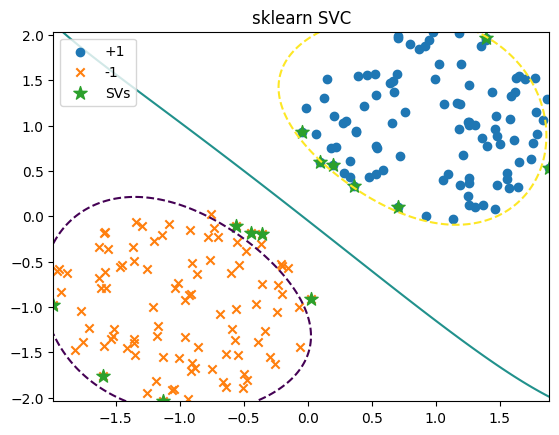

In [8]:
X, Y = load_circle_data()
# Scale
train_x = standardize(X)
#---------------------------------------------------------------------------------------
#---------------------------------Custom SVM SMO----------------------------------------
#---------------------------------------------------------------------------------------
model_custom = SVM_SMO(C=1, kernel='gaussian', max_iter=600, tol=1e-5, eps=1e-5)
model_custom.fit(train_x, Y)
pred_custom = model_custom.predict(train_x)
sv_custom = np.sum(model_custom.alphas > 1e-8)
bias_custom = model_custom.b
err_custom = np.mean(Y * pred_custom < 0)

#---------------------------------------------------------------------------------------
#---------------------------------sklearn SVC-------------------------------------------
#---------------------------------------------------------------------------------------
model_skl = SVC(C=1, kernel='rbf', max_iter=600, tol=1e-5, gamma='scale')
model_skl.fit(train_x, Y)
pred_skl = model_skl.decision_function(train_x)
sv_skl = len(model_skl.support_)
bias_skl = model_skl.intercept_[0]
err_skl = np.mean(Y * np.sign(pred_skl) < 0)
#---------------------------------------------------------------------------------------
#---------------------------------Print comparison--------------------------------------
#---------------------------------------------------------------------------------------

df = pd.DataFrame([
    ['Custom SVM_SMO', sv_custom, bias_custom, err_custom],
    ['sklearn SVC', sv_skl, bias_skl, err_skl]
], columns=['Model', 'SV Count', 'Bias', 'Error Rate'])
print(df.to_string(index=False))
#---------------------------------------------------------------------------------------
#---------------------------------Plot decision boundaries------------------------------
#---------------------------------------------------------------------------------------

plot_decision_boundary(model_custom, X, Y, "Custom SVM_SMO")
plot_decision_boundary(model_skl, X, Y, "sklearn SVC")